<a href="https://colab.research.google.com/github/aashi-singh-web/ML-LAB-CS/blob/main/ML_LAB_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

In [8]:
df = pd.read_csv("/content/wdbc.data")
df.head()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [9]:
df = df.rename(columns={'M': 'diagnosis'})
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]
y = y.map({"M":1, "B":0})

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [13]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.7368421052631579


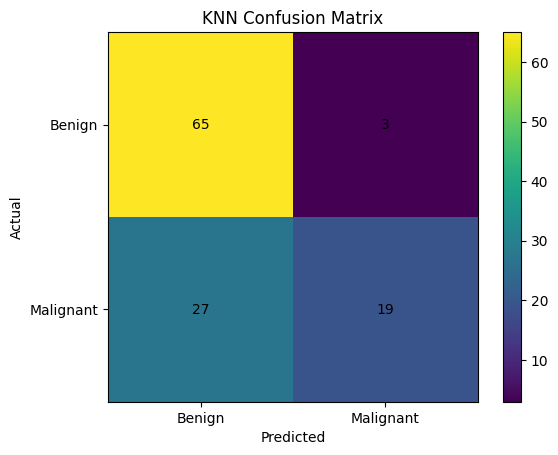

In [14]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.imshow(cm_knn)
plt.title("KNN Confusion Matrix")
plt.colorbar()
plt.xticks([0,1],["Benign","Malignant"])
plt.yticks([0,1],["Benign","Malignant"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm_knn[i][j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.71      0.96      0.81        68
           1       0.86      0.41      0.56        46

    accuracy                           0.74       114
   macro avg       0.79      0.68      0.69       114
weighted avg       0.77      0.74      0.71       114



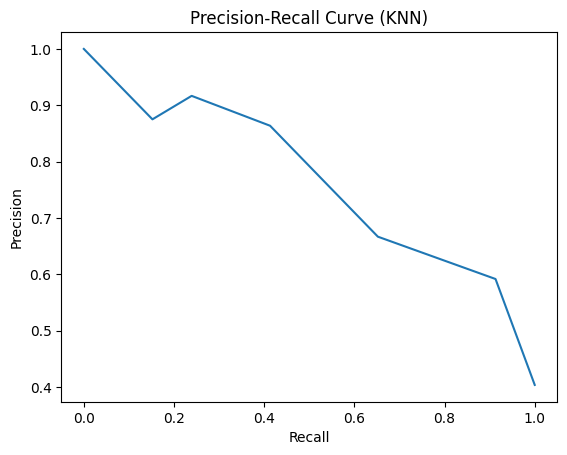

In [16]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_knn)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (KNN)")
plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [19]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9210526315789473


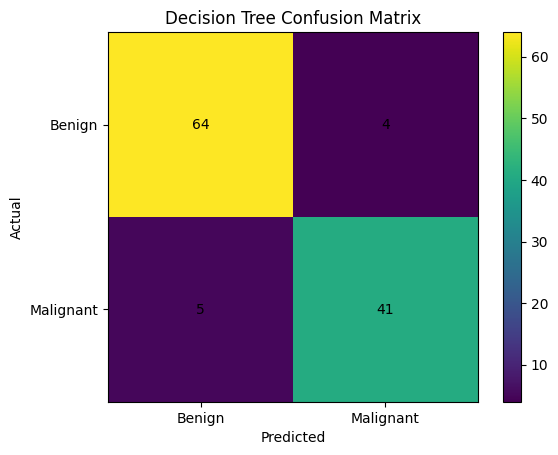

In [20]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.imshow(cm_dt)
plt.title("Decision Tree Confusion Matrix")
plt.colorbar()
plt.xticks([0,1],["Benign","Malignant"])
plt.yticks([0,1],["Benign","Malignant"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm_dt[i][j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93        68
           1       0.91      0.89      0.90        46

    accuracy                           0.92       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



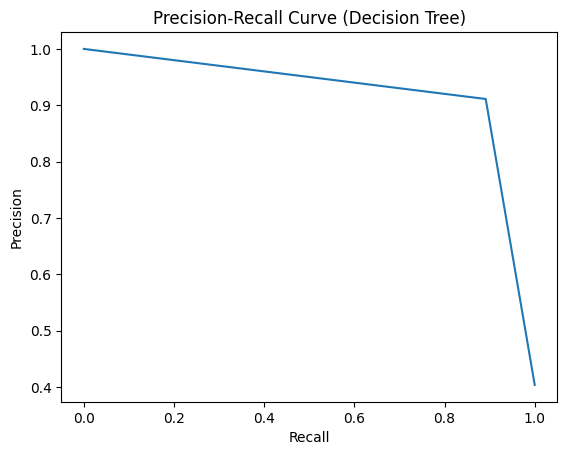

In [22]:
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)
plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Decision Tree)")
plt.show()

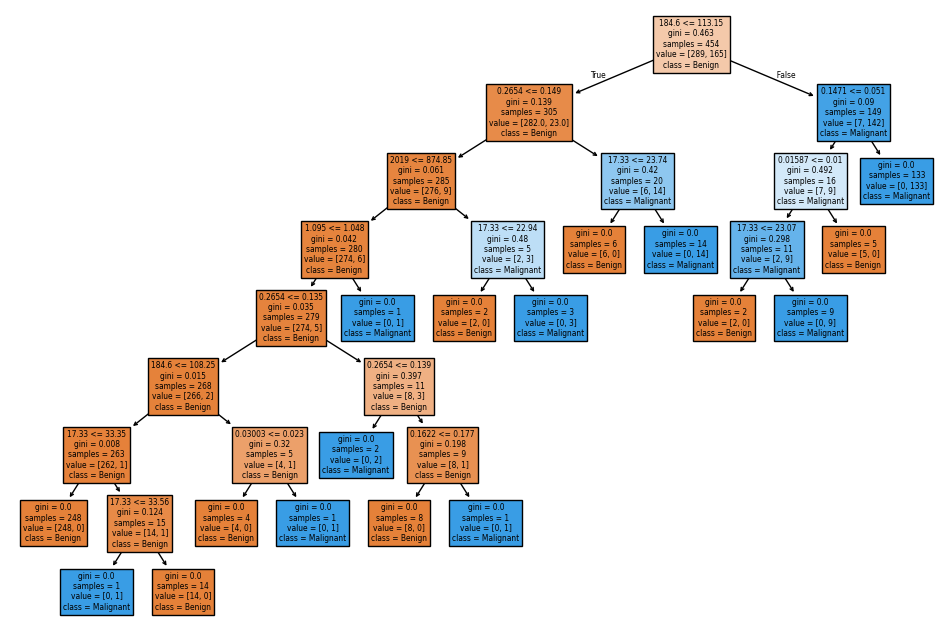

In [23]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(dt,
               feature_names=X.columns,
               class_names=["Benign","Malignant"],
               filled=True)
plt.show()

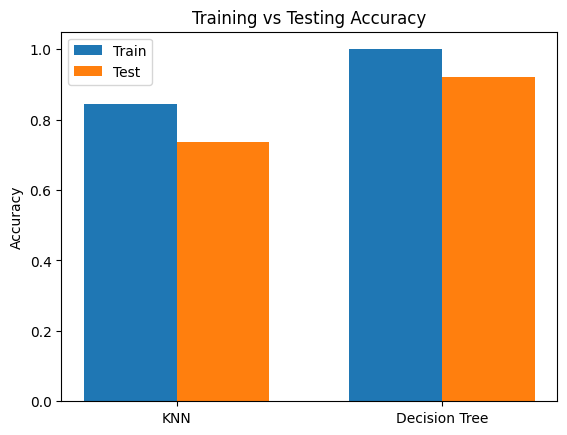

In [24]:
train_knn = knn.score(X_train, y_train)
test_knn = knn.score(X_test, y_test)
train_dt = dt.score(X_train, y_train)
test_dt = dt.score(X_test, y_test)
labels = ["KNN","Decision Tree"]
train_scores = [train_knn, train_dt]
test_scores = [test_knn, test_dt]
x = np.arange(len(labels))
width = 0.35
plt.bar(x-width/2, train_scores, width, label="Train")
plt.bar(x+width/2, test_scores, width, label="Test")
plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

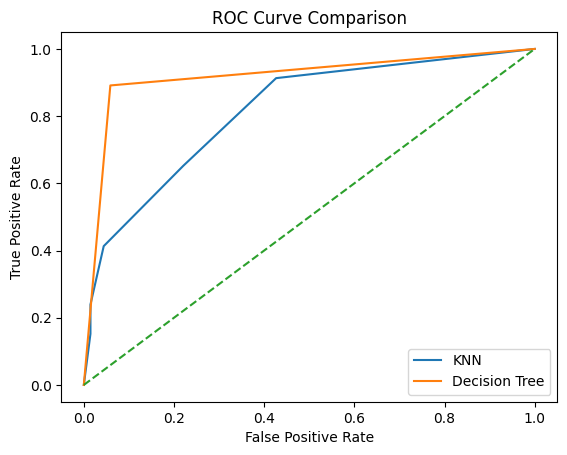

In [25]:
from sklearn.metrics import roc_curve, auc
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

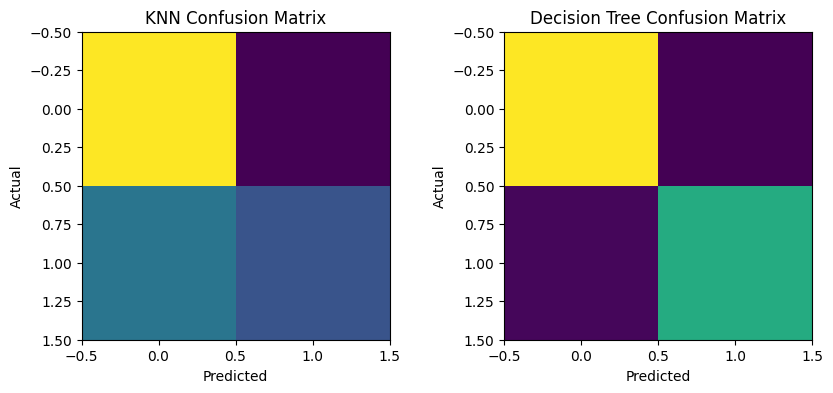

In [26]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].imshow(cm_knn)
ax[0].set_title("KNN Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")
ax[1].imshow(cm_dt)
ax[1].set_title("Decision Tree Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
plt.show()